In [2]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from sklearn.linear_model import LinearRegression

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as pyo
import plotly.io as pio
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

/home/ubuntu/miniconda3/envs/exploratory_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sys.path.append("../config")
import experiment_config

In [4]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from branches import json_to_tree
import interp_utils

In [5]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

In [6]:
# # stupid plotly things
# pyo.init_notebook_mode()
# pio.get_chrome()

In [7]:
TOK_DIR = "./covfit_stuff/Tokenizer"
CONF_DIR = "./covfit_stuff/Config"
TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt"
FOLD_ID = 0
N_TARGETS = 1565
MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt"

In [8]:
# MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
# FOLD_IDS_TO_USE = [0]
# TARGET_FOLD_ID = 0
# OUTPUT_PREFIX = "inference_results"

model_name = "facebook/esm2_t33_650M_UR50D"
device = experiment_config.device
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)
torch.set_float32_matmul_precision("medium")

In [9]:
esm_fine_tuned = interp_utils.get_model()

In [10]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [11]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name
REPO_ID = esm_config.model_name
original_task_id_infos = torch.load(TASK_IDS_FILE, map_location=device)

In [12]:
tokenizer_config = {}
special_tokens_map_file = "./covfit_stuff/Tokenizer/special_tokens_map.json"
tokenizer_config["vocab_file"] = "./covfit_stuff/Tokenizer/vocab.txt"
tokenizer_config["model_max_length"] = CONTEXT_LEN

with open("./covfit_stuff/Tokenizer/special_tokens_map.json", "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [13]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

In [14]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = interp_utils.get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(interp_utils.get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [15]:
# clean up memory
torch.cuda.empty_cache()

# Load Data

In [16]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [17]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [18]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [19]:
name_to_clade_dict = dict()
for suff in pathogen_suffixes:
    print(suff)
    with open(f"../data/pathogen/{pathogen_name}_{suff}/auspice.json", "r") as f:
        tree_json = json.load(f)
        test_tree = json_to_tree(tree_json)
        nodes = list(test_tree.find_clades(order="postorder"))
        name_to_clade_dict.update({n.name:n.node_attrs["clade_membership"]["value"] for n in nodes})

africa
asia
europe
north_america
oceania
south_america


In [20]:
"""
all_uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4558
torch.Size([4558, 1024])


In [21]:
hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = interp_utils.add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [22]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [23]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = interp_utils.get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [24]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

In [25]:
logit_id = original_task_id_infos["fitness_USA"]

# Looping through muts

In [26]:
corresponding_heads = {
    "G339H": [(31,7), (32,5), (32,8)],
    "R346T": [(31,7), (32,5), (32,8)],
    "K417N": [(31,7), (32,5), (32,8)],
    "V445P": [(31,7), (32,5), (32,8)],
    "L455F": [(31,7), (32,5), (32,8), (32,13)],
    "F456L": [(32,5), (32,8), (32,13)],
    "E484A": [(31,7), (32,5), (32,8)],
    "S486P": [(32,5), (32,8)],
    "Q493R": [(31,7), (32,5), (32,8)],
    "P681H": [(31,7), (32,8)],
}

In [27]:
relevant_mutations = [
    ("G339H", lambda x: x <= "21M"),
    ("R346T", lambda x: "XBB" in x),
    ("K417N", lambda x: True), 
    ("V445P", lambda x: x <= "23I"),
    ("L455F", lambda x: True),
    ("F456L", lambda x: x.endswith("(XBB.1.5)")),
    ("E484A", lambda x: x <= "21M"),
    ("S486P", lambda x: "XBB" in x or "JN" in x or "21" in x),
    ("Q493R", lambda x: x <= "21M"),
    ("P681H", lambda x: x <= "23I"),
]

wt_mut_seq_pairs = dict()

In [28]:
np.random.seed(0)
for mut, seq_selector in relevant_mutations:
    wt_resid = mut[0]
    mut_resid = mut[-1]
    site = int(mut[1:-1])

    uniq_seqs = np.unique([all_uniq_seqs[seq_idxs[i]] for i,n in enumerate(seq_names) if seq_selector(name_to_clade_dict[n])])
    rand_seqs = np.random.permutation(uniq_seqs)

    seq_orig_idx = [x for x in rand_seqs if x[site-1] == wt_resid][:80]
    seq_new_idx = [x[:site-1] + mut_resid + x[site:] for x in seq_orig_idx]

    print(f"Mutation = {wt_resid} {site} {mut_resid}; {seq_orig_idx[10][site-1]}, {seq_new_idx[10][site-1]}; {len(seq_orig_idx)} total seqs")

    seq_orig_toks = tokenizer(seq_orig_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
    seq_new_toks = tokenizer(seq_new_idx, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
    wt_mut_seq_pairs[mut] = (seq_orig_toks, seq_new_toks)

    sanity_check = (wt_mut_seq_pairs[mut][0] !=  wt_mut_seq_pairs[mut][1]).sum(dim=0)
    print(torch.arange(seq_orig_toks.shape[-1])[sanity_check.to(bool).cpu()].item(), sanity_check[site].item(), "\n")

Mutation = G 339 H; G, H; 80 total seqs
339 80 

Mutation = R 346 T; R, T; 80 total seqs
346 80 

Mutation = K 417 N; K, N; 80 total seqs
417 80 

Mutation = V 445 P; V, P; 80 total seqs
445 80 

Mutation = L 455 F; L, F; 80 total seqs
455 80 

Mutation = F 456 L; F, L; 80 total seqs
456 80 

Mutation = E 484 A; E, A; 80 total seqs
484 80 

Mutation = S 486 P; S, P; 80 total seqs
486 80 

Mutation = Q 493 R; Q, R; 80 total seqs
493 80 

Mutation = P 681 H; P, H; 80 total seqs
681 80 



In [167]:
fitness_incs = []
# for mut, seq_selector in relevant_mutations:
for mut in wt_mut_seq_pairs.keys():
    seq_orig_toks, seq_new_toks = wt_mut_seq_pairs[mut]
    wt_resid = mut[0]
    mut_resid = mut[-1]
    site = int(mut[1:-1])

    seq_orig_output = get_logit_hooked(hooked_esm(seq_orig_toks), logit_id)
    torch.cuda.empty_cache()
    seq_new_output = get_logit_hooked(hooked_esm(seq_new_toks), logit_id)
    torch.cuda.empty_cache()
    diffs = (seq_new_output - seq_orig_output).cpu().numpy()
    fitness_incs.append(diffs)
    print(f"{mut} Sanity check -- mean diff: {diffs.mean().item()}, min diff: {diffs.min().item()}, max diff: {diffs.max().item()}\n")

G339H Sanity check -- mean diff: 0.03425808995962143, min diff: -0.0028573572635650635, max diff: 0.09988410770893097

R346T Sanity check -- mean diff: 0.015634644776582718, min diff: -0.007566183805465698, max diff: 0.09253817796707153

K417N Sanity check -- mean diff: 0.028336893767118454, min diff: -0.0033425837755203247, max diff: 0.13782092928886414

V445P Sanity check -- mean diff: 0.1648654192686081, min diff: 0.008002042770385742, max diff: 0.3650940954685211

L455F Sanity check -- mean diff: 0.011739089153707027, min diff: -0.0043255239725112915, max diff: 0.025897622108459473

F456L Sanity check -- mean diff: 0.03130492568016052, min diff: 0.015691429376602173, max diff: 0.05709803104400635

E484A Sanity check -- mean diff: 0.05911920219659805, min diff: 0.0007587969303131104, max diff: 0.14487341046333313

S486P Sanity check -- mean diff: 0.02791418507695198, min diff: 0.02003169059753418, max diff: 0.03881633281707764

Q493R Sanity check -- mean diff: 0.07368779182434082, m

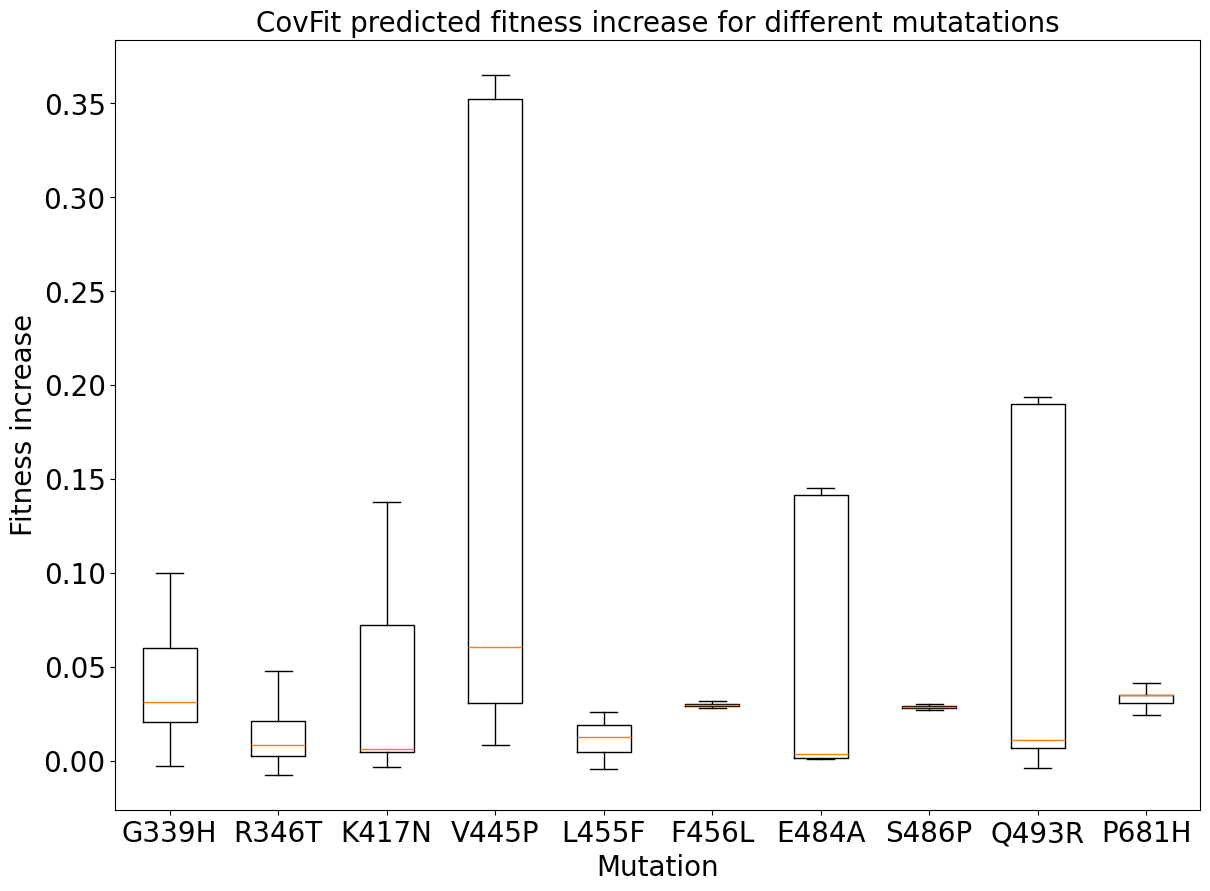

In [53]:
fitness_incs_np = np.stack(fitness_incs, axis=0)
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.boxplot(fitness_incs_np.T, showfliers=False)
ax.set_title("CovFit predicted fitness increase for different mutatations", fontsize=20)
ax.set_xticks(np.arange(fitness_incs_np.shape[0]) + 1, [x[0] for x in relevant_mutations], fontsize=20)
ax.tick_params(axis='y', labelsize=20)
plt.ylabel('Fitness increase', fontsize=20)
plt.xlabel('Mutation', fontsize=20)
plt.savefig("../figures/more_mut_diff_plot.png")
plt.show()

# Re-running experiments with new muts

In [54]:
def plot_lines_over_time(
    ax,
    new_toks,
    orig_toks,
    model,
    logit_id=logit_id
):
    resid_component_names = ["blocks.0.hook_resid_pre"]
    for layer in range(hooked_esm.cfg.n_layers):
        resid_mid_name = f"blocks.{layer}.hook_resid_mid"
        resid_post_name = f"blocks.{layer}.hook_resid_post"
        resid_component_names.append(resid_mid_name)
        resid_component_names.append(resid_post_name)
        
    def patch_resid_direct_to_regressor(toks: Float[Tensor, "n_data d_vocab"]):
        n_data = toks.size(0)
        _, resid_cache = model.run_with_cache(toks, names_filter=resid_component_names)
        torch.cuda.empty_cache()
    
        logit_results = torch.zeros(n_data, len(resid_component_names)).to(device) #[n_data n_components]
        final_ln = model.ln_final
    
        # run regressor model on residual stream at each layer (including before attn0 and after final layer norm)
        for i, component in enumerate(resid_component_names):
            resid_component = final_ln(resid_cache[component])
            logit_results[:, i] = get_logit_hooked(resid_component, tok_id=logit_id)
        del _
        del resid_cache
        torch.cuda.empty_cache()
        
        return logit_results

    high_resid_layer_results = patch_resid_direct_to_regressor(new_toks)
    torch.cuda.empty_cache()
    low_resid_layer_results = patch_resid_direct_to_regressor(orig_toks)
    torch.cuda.empty_cache()

    for j in range(high_resid_layer_results.shape[0]):
        ax.plot(list(range(len(resid_component_names))), high_resid_layer_results[j].cpu().numpy() - low_resid_layer_results[j].cpu().numpy(), color="red", alpha=0.3)
    ax.plot(list(range(len(resid_component_names))), high_resid_layer_results.mean(dim=0).cpu().numpy() - low_resid_layer_results.mean(dim=0).cpu().numpy(), color="black")
    
    ax.plot(
        [-0.5, len(resid_component_names)+0.5], 
        [high_resid_layer_results[:,-1].cpu().mean() - low_resid_layer_results[:,-1].cpu().mean() for _ in range(2)], 
        linestyle="dashed", 
        color="black"
    )

Mutation = G 339 H;
Mutation = R 346 T;
Mutation = K 417 N;
Mutation = V 445 P;
Mutation = L 455 F;
Mutation = F 456 L;
Mutation = E 484 A;
Mutation = S 486 P;
Mutation = Q 493 R;
Mutation = P 681 H;


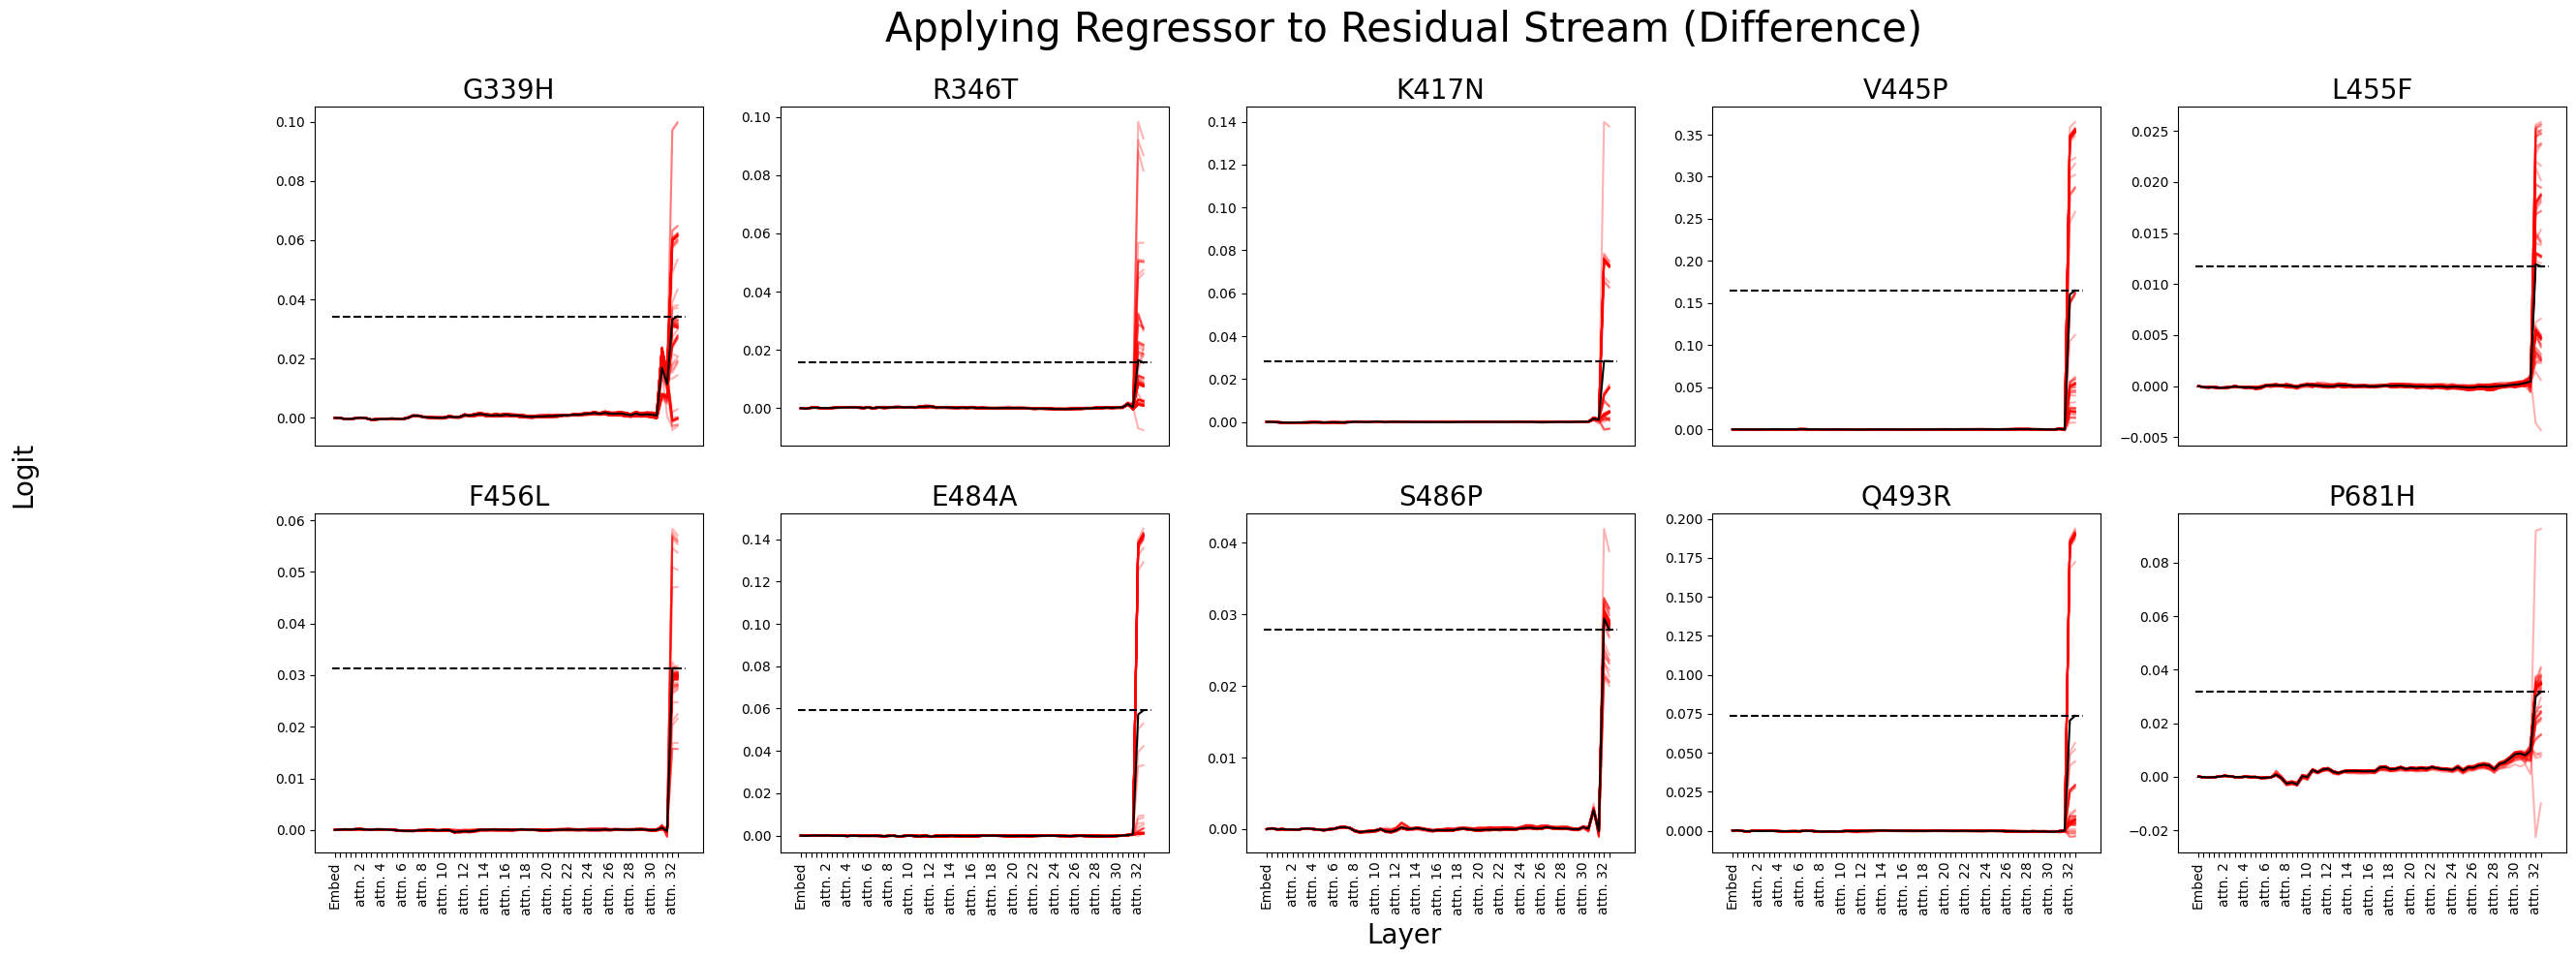

In [59]:
np.random.seed(0)
# display results
fig, ax = plt.subplots(2,5,figsize=(30,10))
for i, mut in enumerate(wt_mut_seq_pairs.keys()):
    (seq_orig_toks, seq_new_toks) = wt_mut_seq_pairs[mut]
    wt_resid = mut[0]
    mut_resid = mut[-1]
    site = int(mut[1:-1])

    print(f"Mutation = {wt_resid} {site} {mut_resid};")

    row = i // 5
    col = i % 5
    
    plot_lines_over_time(ax[row,col], new_toks=seq_new_toks, orig_toks=seq_orig_toks, model=hooked_esm)
    ax[row,col].set_title(f"{mut}", fontsize=20)
    fig.suptitle("Applying Regressor to Residual Stream (Difference)", fontsize=30)
    if row == 1:
        ax[row,col].set_xticks(
            np.arange(hooked_esm.cfg.n_layers * 2 + 1), 
            labels=["Embed", *[f"attn. {idx // 2}" if idx % 4 == 0 and idx != 0 else "" for idx in range(66)]], 
            rotation=90,
            fontsize=10
        )
    else:
        ax[row,col].set_xticks([])

fig.supxlabel("\nLayer", fontsize=20)
fig.supylabel("Logit", fontsize=20)
# plt.tight_layout()
plt.savefig("../figures/more_mut_resid_stream.png")
plt.show()

# QK-circuit analysis

In [29]:
# Investigate 484,954 -> 679
# 686 is COMPLETELY CONSERVED REGION

# G339H -- 31.7 for tok 679 (at pos 339)
# R346T -- 32.8, 32.6 at tok 0 (at pos 346), investigate 679 and 339
# K417N -- 31.7 for tok 679 (at pos 417)
# V445P -- 31.7 for tok 679 (at pos 445)
# L455F -- 31.7 for tok 679  (at pos 455)
# F456L -- 32.5, 32.8 at tok 0 (at pos 456)
# E484A -- 31.7 at tok 679, (at pos 484)
# S486P 
# Q493R -- 31.7 at tok 679, (at pos 493)
# P681H

In [30]:
def get_heads_of_interest_orig_mut(mut, layer_head_list, seq_orig_toks, seq_new_toks, model=hooked_esm):
    all_layers = list(set([layer_head[0] for layer_head in layer_head_list]))
    all_layers.sort()
    
    attn_keys = [utils.get_act_name("pattern",x) for x in all_layers]
    
    model.reset_hooks(including_permanent=False)
    _, attn_cache_orig = hooked_esm.run_with_cache(seq_orig_toks, names_filter=attn_keys)
    torch.cuda.empty_cache()
    _, attn_cache_mut = hooked_esm.run_with_cache(seq_new_toks, names_filter=attn_keys)
    torch.cuda.empty_cache()

    attn_orig_mean_std = []
    attn_mut_mean_std = []
    for (layer, head) in layer_head_list:
        layer_key = utils.get_act_name("pattern",layer)

        for cache, record in zip([attn_cache_orig, attn_cache_mut], [attn_orig_mean_std, attn_mut_mean_std]):
            attn_val = None
            if layer == 32:
                attn_val = cache[layer_key][:, head, 0, :] # original shape Tensor[batch, n_head, q_seq_len, k_seq_len], only care about cls tok
            else:
                attn_val = cache[layer_key][:, head, :, :]

            record.append((attn_val.mean(dim=0), attn_val.std(dim=0)))
            
    return attn_orig_mean_std, attn_mut_mean_std

In [31]:
def plot_orig_mut_attn_col(
    orig_attn, 
    mut_attn,
    disp_width = 1100,
    disp_height = 500,
    disp_title="",
    disp_col_label=""
):
    """
    orig_attn, mut_attn - Tensor[seq_len]
    """
    disp_tensor = torch.stack([orig_attn, mut_attn], dim=0).cpu()
    fig = imshow(
        disp_tensor.view(-1,32,32),
        facet_col=0,
        x=np.arange(32),
        y=np.arange(32),
        width=disp_width, 
        height=disp_height, 
        facet_labels=[f"{disp_col_label} clean", f"{disp_col_label} mut"], 
        title=disp_title,
        return_fig=True,
    )
    fig.update_traces(customdata=np.arange(1024).reshape(32,32), hovertemplate="%{x}, %{y}<br>Sequence position: 0 <- %{customdata}<br>Attn Prob. %{z}")
    fig.show()
    torch.cuda.empty_cache()
    return fig

In [227]:
mut_i = relevant_mutations[9][0]
print(mut_i)
(seq_orig_toks, seq_new_toks) = wt_mut_seq_pairs[mut_i]
layer_head_list_i = corresponding_heads[mut_i]
attn_orig_mean_std, attn_mut_mean_std = get_heads_of_interest_orig_mut(mut_i, layer_head_list_i, seq_orig_toks, seq_new_toks)

P681H


In [228]:
# del attn_orig_mean_std
# del attn_mut_mean_std
# torch.cuda.empty_cache()

31 7


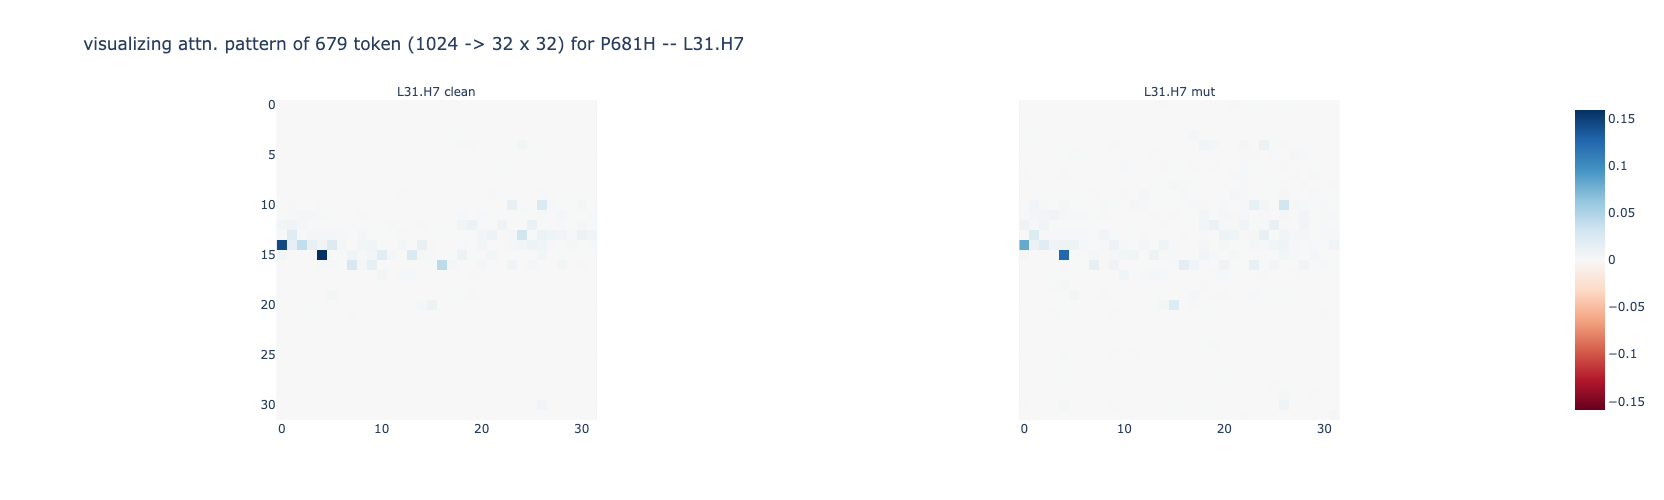

32 8


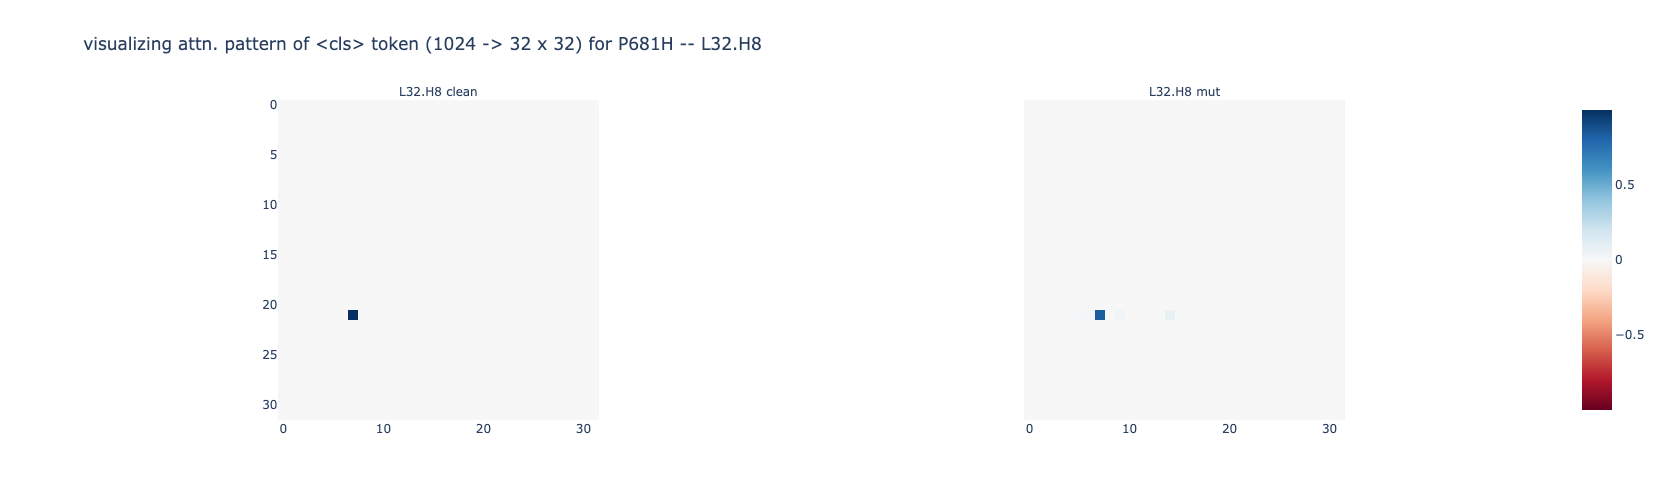

In [231]:
for i, (layer, head) in enumerate(layer_head_list_i):
    print(layer, head)
    (attn_orig_mean, attn_orig_std) = attn_orig_mean_std[i]
    (attn_mut_mean, attn_mut_std) = attn_mut_mean_std[i]
    if layer == 32:
        fig = plot_orig_mut_attn_col(
            attn_orig_mean, 
            attn_mut_mean, 
            disp_title=f"visualizing attn. pattern of <cls> token (1024 -> 32 x 32) for {mut_i} -- L{layer}.H{head}",
            disp_col_label = f"L{layer}.H{head}"
        )
    if layer == 31:
        N = 679
        fig = plot_orig_mut_attn_col(
            attn_orig_mean[N,:], 
            attn_mut_mean[N,:], 
            disp_title=f"visualizing attn. pattern of {N} token (1024 -> 32 x 32) for {mut_i} -- L{layer}.H{head}",
            disp_col_label = f"L{layer}.H{head}"
        )
    torch.cuda.empty_cache()

In [33]:
mut_has_679_k_comp = {
    "G339H": True,
    "R346T": False,
    "K417N": True,
    "V445P": True,
    "L455F": True,
    "F456L": False,
    "E484A": True,
    "S486P": False,
    "Q493R": True,
    "P681H": False,
}

In [36]:
mut_i = relevant_mutations[0][0]
(seq_orig_toks, seq_new_toks) = wt_mut_seq_pairs[mut_i]
layer_head_list_i = corresponding_heads[mut_i]
attn_orig_mean_std, attn_mut_mean_std = get_heads_of_interest_orig_mut(mut_i, layer_head_list_i, seq_orig_toks, seq_new_toks)

In [ ]:
# del attn_orig_mean_std
# del attn_mut_mean_std
# torch.cuda.empty_cache()

G339H
31 7
32 5
32 8


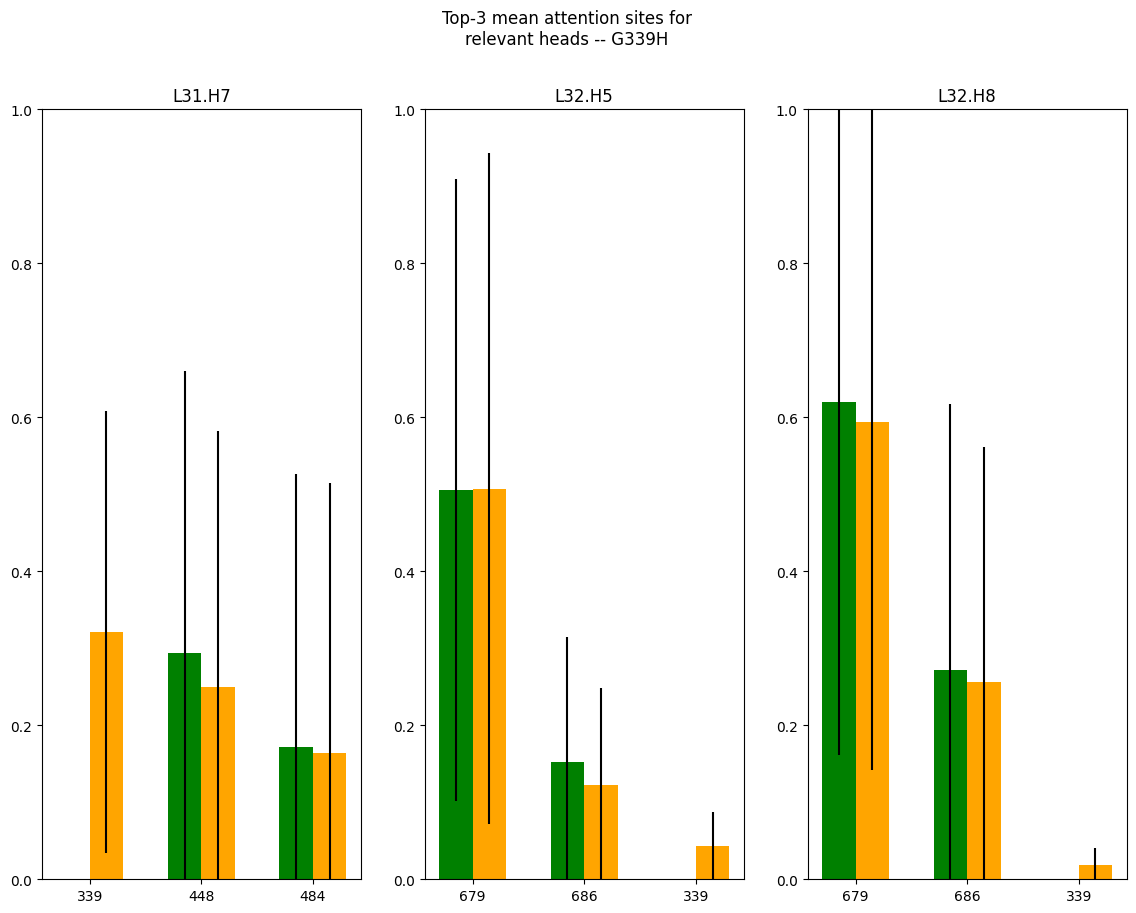

In [69]:
num_topk = 3

# for (mut_i, _) in relevant_mutations:
for mut_i in [relevant_mutations[0][0]]:
    print(mut_i)
    fig, ax = plt.subplots(1,len(layer_head_list_i),figsize=(14,10))
    for i, (layer, head) in enumerate(layer_head_list_i):
        print(layer, head)
        (attn_orig_mean, attn_orig_std) = attn_orig_mean_std[i]
        (attn_mut_mean, attn_mut_std) = attn_mut_mean_std[i]

        if layer == 31 and mut_has_679_k_comp[mut_i]:
            attn_orig_mean = attn_orig_mean[679, :]
            attn_orig_std = attn_orig_std[679, :]
            
            attn_mut_mean = attn_mut_mean[679, :]
            attn_mut_std = attn_mut_std[679, :]
        elif layer == 31:
            continue
            
        max_vals, max_tok_idx = attn_mut_mean.topk(k=num_topk,dim=-1)
        ax[i].bar(torch.arange(num_topk) - 0.15, attn_orig_mean[max_tok_idx].cpu(), yerr=attn_orig_std[max_tok_idx].cpu(), width=0.3, color="green")
        ax[i].bar(torch.arange(num_topk) + 0.15, attn_mut_mean[max_tok_idx].cpu(), yerr=attn_mut_std[max_tok_idx].cpu(), width=0.3, color="orange")
        ax[i].set_xticks(torch.arange(num_topk), labels=max_tok_idx.cpu().numpy())
        ax[i].set_title(f"L{layer}.H{head}")
        ax[i].set_ylim([0,1])
        fig.suptitle(f"Top-3 mean attention sites for\nrelevant heads -- {mut_i}")
        
    torch.cuda.empty_cache()
    break

# F456L QK-circuit (XBB.1.5 seqs)

In [35]:
hooked_esm.reset_hooks(including_permanent=False)
attn_keys = [utils.get_act_name("pattern",x) for x in [31,32]]


_, attn_cache_orig = hooked_esm.run_with_cache(orig_toks, names_filter=attn_keys)
torch.cuda.empty_cache()
_, attn_cache_mut = hooked_esm.run_with_cache(new_toks, names_filter=attn_keys)
torch.cuda.empty_cache()

In [36]:
attn_32_orig = attn_cache_orig[attn_keys[-1]]
attn_32_mut = attn_cache_mut[attn_keys[-1]]

attn_31_orig = attn_cache_orig[attn_keys[0]]
attn_31_mut = attn_cache_mut[attn_keys[0]]

In [37]:
heads_of_interest = [(32,5), (32,8), (32,13), (31,7), (31,17)]

attn_32_orig_cls = attn_32_orig[:, [x[1] for x in heads_of_interest if x[0] == 32], 0, :]
attn_32_mut_cls = attn_32_mut[:, [x[1] for x in heads_of_interest if x[0] == 32], 0, :]

attn_31_orig_cls = attn_31_orig[:, [x[1] for x in heads_of_interest if x[0] == 31], 456, :]
attn_31_mut_cls = attn_31_mut[:, [x[1] for x in heads_of_interest if x[0] == 31], 456, :]

attn_orig_cls = torch.cat([attn_32_orig_cls, attn_31_orig_cls], dim=1)
attn_mut_cls = torch.cat([attn_32_mut_cls, attn_31_mut_cls], dim=1)

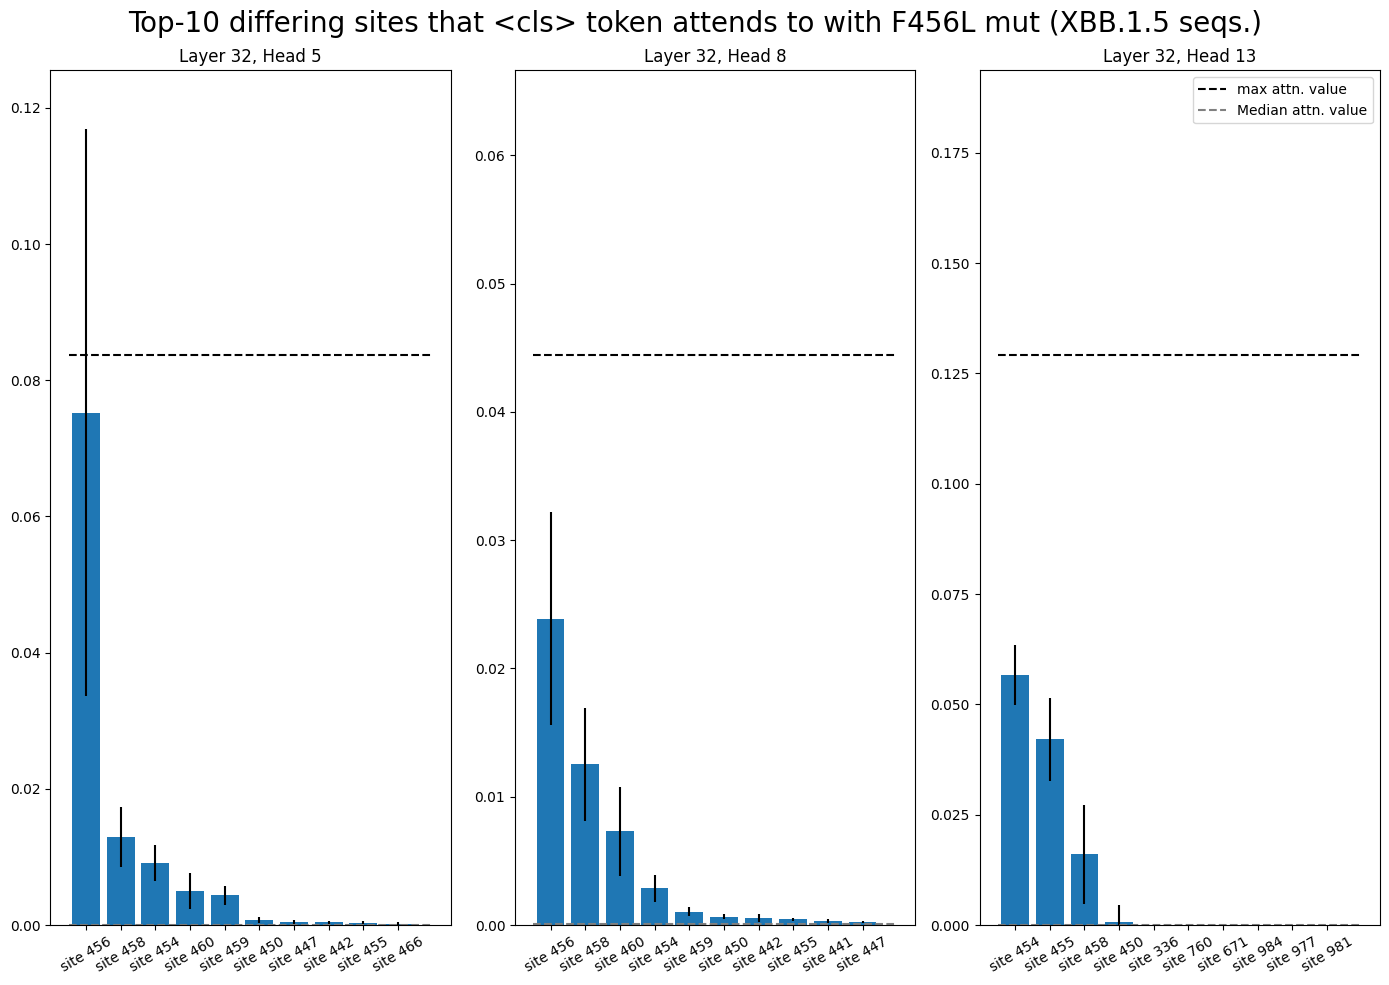

In [39]:
num_topk = 10
l32_heads = [x for x in heads_of_interest if x[0] == 32]
fig, ax = plt.subplots(1,3,figsize=(14,10))
diff_tok_idxs = attn_32_mut_cls - attn_32_orig_cls
max_diff_vals, max_diff_tok_idx = diff_tok_idxs.mean(dim=0).topk(k=num_topk,dim=-1)
max_attn_vals_mut = attn_32_mut_cls.mean(dim=0).max(dim=-1).values
median_attn_vals_mut = torch.median(attn_32_mut_cls.mean(dim=0), axis=-1).values
std_vals = torch.std(diff_tok_idxs, dim=0)

for i, ax_i in enumerate(ax):
    ax_i.bar(list(range(num_topk)), max_diff_vals[i,:].cpu(), yerr=std_vals[i,max_diff_tok_idx[i]].cpu())
    ax_i.set_xticks(list(range(num_topk)), labels=[f"site {x}" for x in max_diff_tok_idx[i,:].cpu()], rotation=30)
    ax_i.set_title(f"Layer 32, Head {l32_heads[i][1]}")
    ax_i.plot([-0.5,num_topk], [max_attn_vals_mut[i].cpu() for _ in range(2)], linestyle="dashed", label="max attn. value", color="black")
    ax_i.plot([-0.5,num_topk], [median_attn_vals_mut[i].cpu() for _ in range(2)], linestyle="dashed", label="Median attn. value", color="grey")
    ax_i.set_ylim([0, max_attn_vals_mut[i].cpu() * 1.5])
    if i == len(ax) - 1:
        ax_i.legend()
fig.suptitle(f"Top-{num_topk} differing sites that <cls> token attends to with F456L mut (XBB.1.5 seqs.)", fontsize=20)
plt.tight_layout()
plt.show()